In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

#fitters

import pybobyqa
import time
import cma
import csv

Which Fit?

In [2]:
fit_name = "MAP-FD"

Read Files

In [3]:
Main.fit_name = str(fit_name)

TMD_fitting_root = "../"
def include(name):
    path = os.path.join(TMD_fitting_root, name)
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")
include("DY/DY_table_FD.jl")

# Data
data_name = Main.data_name
table_name = Main.table_name

file_root = f"../Data/{data_name}/Cutted/DY"
matrix_root = f"../Data/{data_name}/Covariance_Matrices/DY"
table_root = f"../Tables_JLD2/{table_name}/DY"

initial_params = Main.initial_params

In [4]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    df[num_cols] = df[num_cols].astype("float64")
    return df

df_predictions = dict([])

By file or by experiment?

In [5]:
data_selections = "by_experiment"  # "by_file" or "by_experiment"

In [6]:
experiments =[
    #'ATLAS_7',
    'ATLAS_8', 
    #'ATLAS_13', 
    'CDF_I',
    'CDF_II',
    'CMS_7',
    'CMS_8',
    'CMS_13',    
    'D0_I',
    'D0_II',
    'D0_II_mu',
    'E288',
    'E605',
    'E772',
    'LHCb_7',
    'LHCb_8',
    'LHCb_13',    
    #'PHENIX',
    'STAR'
]

#["E288","E605","E772","ATLAS", "CMS", "D0", "CDF", "LHCb", "PHENIX", "STAR"]

In [7]:
from pathlib import Path

if data_selections == "by_experiment":
    file_names = []
    for experiment in experiments:
        exp_dir = Path(file_root) / experiment
        for p in sorted(exp_dir.glob("*.csv")):
            file_names.append(str(Path(experiment) / p.name)) 

display(file_names)

['ATLAS_8\\ATLAS8-00y04.csv',
 'ATLAS_8\\ATLAS8-04y08.csv',
 'ATLAS_8\\ATLAS8-08y12.csv',
 'ATLAS_8\\ATLAS8-116Q150.csv',
 'ATLAS_8\\ATLAS8-12y16.csv',
 'ATLAS_8\\ATLAS8-16y20.csv',
 'ATLAS_8\\ATLAS8-20y24.csv',
 'ATLAS_8\\ATLAS8-46Q66.csv',
 'CDF_I\\CDF1.csv',
 'CDF_II\\CDF2.csv',
 'CMS_7\\CMS7.csv',
 'CMS_8\\CMS8.csv',
 'CMS_13\\CMS13-00y04.csv',
 'CMS_13\\CMS13-04y08.csv',
 'CMS_13\\CMS13-08y12.csv',
 'CMS_13\\CMS13-12y16.csv',
 'CMS_13\\CMS13-16y24.csv',
 'D0_I\\D01.csv',
 'D0_II\\D02.csv',
 'D0_II_mu\\D02mu.csv',
 'E288\\E228-200-4Q5.csv',
 'E288\\E228-200-5Q6.csv',
 'E288\\E228-200-6Q7.csv',
 'E288\\E228-200-7Q8.csv',
 'E288\\E228-200-8Q9.csv',
 'E288\\E228-300-11Q12.csv',
 'E288\\E228-300-4Q5.csv',
 'E288\\E228-300-5Q6.csv',
 'E288\\E228-300-6Q7.csv',
 'E288\\E228-300-7Q8.csv',
 'E288\\E228-300-8Q9.csv',
 'E288\\E228-400-11Q12.csv',
 'E288\\E228-400-12Q13.csv',
 'E288\\E228-400-13Q14.csv',
 'E288\\E228-400-5Q6.csv',
 'E288\\E228-400-6Q7.csv',
 'E288\\E228-400-7Q8.csv',
 'E288\\E

Read Data

In [8]:
data_list = dict()
matrix_list = dict()

for file in tqdm(file_names):

    df_data = to_float64(pd.read_csv(f"{file_root}/{file}"))
    data_list[file] = df_data
    
    matrix = to_float64(pd.read_csv(f"{matrix_root}/{file}"))
    matrix_list[file] = matrix

data_list_raw = data_list

100%|██████████| 55/55 [00:00<00:00, 273.18it/s]


Prediction

In [9]:
Params = Main.Params_Struct(*[np.float32(x) for x in initial_params]) 
#Main.set_params(Main.VRAM, Params) 

for i in range(10):
    Params = Main.Params_Struct(*[np.float32(x) for x in initial_params])                  
    predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    print(round(t*1000,2), "ms")

374.26 ms
79.67 ms
79.56 ms
79.35 ms
79.13 ms
79.06 ms
79.31 ms
79.25 ms
79.2 ms
79.35 ms


In [10]:
def get_file_length():

    file_lengths = dict()

    for file in file_names:

        df = to_float64(pd.read_csv(f"{file_root}/{file}"))

        file_lengths[file] = len(df)

    return file_lengths

file_lengths = get_file_length()

In [11]:
def _norm(p: str) -> str:
    return os.path.normpath(p).replace('\\', '/')

def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}  # normalize keys once
    df_predictions = {}

    for file in file_names:
        n = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []
        for i in range(n):
            table_path = _norm(os.path.join(table_root, f"{base}/{i}.jld2"))
            xs.append(preds[table_path])
        df_predictions[file] = np.array(xs)

    return df_predictions

df_predictions = prediction_reformat(predictions)


Chi2

In [12]:
ASWZ_b_array = np.linspace(0.12,0.78,12)*5.067731
ASWZ_prediction = np.array([
    -0.08158508158508182,
    -0.1701631701631705,
    -0.2400932400932403,
    -0.34265734265734293,
    -0.37062937062937085,
    -0.4265734265734267,
    -0.4498834498834501,
    -0.44522144522144536,
    -0.4965034965034967,
    -0.5710955710955714,
    -0.6363636363636365,
    -0.7016317016317017
    ])
ASWZ_upper = np.array([
    0.18414918414918402,
    0.11421911421911402,
    0.09557109557109533,
    0.002331002331002141,
    0.016317016317016098,
    -0.034965034965035224,
    -0.034965034965035224,
    -0.011655011655011815,
    -0.034965034965035224,
    -0.05361305361305391,
    -0.05827505827505863,
    -0.04895104895104918
    ])
ASWZ_error = np.array(ASWZ_upper) - np.array(ASWZ_prediction)

def chi2_lattice(): 
    CS_list = []
    for b in ASWZ_b_array :
        Q = 2.0
        CS = Main.CS_total_func(b, Q)
        CS_list.append(CS)
    chi2dN = np.sum( (CS_list - ASWZ_prediction)**2 / ASWZ_error**2 ) / len(ASWZ_b_array)
    return chi2dN

def timed(func):
    t0 = time.perf_counter()
    out = func()
    return out, time.perf_counter() - t0

#chi2dN, t = timed(chi2_lattice)
#print("χ^2/N from LATTICE =", chi2dN, ", took", round(t, 4), "seconds")

In [13]:
def get_chi2dN(df_predictions):

    N_list = dict()
    chi2dN_list = dict()
    chi2_total = 0.0
    N_total = 0

    for file in file_names:

        data_xsec = data_list[file]["xsec"].to_numpy()
        pred_xsec = df_predictions[file]
        diff_xsec = data_xsec - pred_xsec

        covariance_matrix_inv = matrix_list[file].to_numpy()

        N = len(data_xsec)

        chi2 = diff_xsec @ covariance_matrix_inv @ diff_xsec

        chi2_total += chi2
        N_total += N
        chi2dN_list[file] = float(round(chi2/N, 2))
        N_list[file] = N

    chi2dN = chi2_total / N_total
    return chi2dN, chi2dN_list, N_list

chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

print(f"Total χ^2/N = {chi2dN:.2f}")
display(chi2dN_list)

Total χ^2/N = 1.32


{'ATLAS_8\\ATLAS8-00y04.csv': 5.8,
 'ATLAS_8\\ATLAS8-04y08.csv': 4.73,
 'ATLAS_8\\ATLAS8-08y12.csv': 4.0,
 'ATLAS_8\\ATLAS8-116Q150.csv': 0.61,
 'ATLAS_8\\ATLAS8-12y16.csv': 6.72,
 'ATLAS_8\\ATLAS8-16y20.csv': 4.72,
 'ATLAS_8\\ATLAS8-20y24.csv': 2.35,
 'ATLAS_8\\ATLAS8-46Q66.csv': 2.09,
 'CDF_I\\CDF1.csv': 0.59,
 'CDF_II\\CDF2.csv': 1.39,
 'CMS_7\\CMS7.csv': 1.59,
 'CMS_8\\CMS8.csv': 1.59,
 'CMS_13\\CMS13-00y04.csv': 2.13,
 'CMS_13\\CMS13-04y08.csv': 1.41,
 'CMS_13\\CMS13-08y12.csv': 0.36,
 'CMS_13\\CMS13-12y16.csv': 0.21,
 'CMS_13\\CMS13-16y24.csv': 0.25,
 'D0_I\\D01.csv': 0.53,
 'D0_II\\D02.csv': 0.5,
 'D0_II_mu\\D02mu.csv': 0.22,
 'E288\\E228-200-4Q5.csv': 0.25,
 'E288\\E228-200-5Q6.csv': 0.78,
 'E288\\E228-200-6Q7.csv': 0.92,
 'E288\\E228-200-7Q8.csv': 0.99,
 'E288\\E228-200-8Q9.csv': 0.68,
 'E288\\E228-300-11Q12.csv': 0.24,
 'E288\\E228-300-4Q5.csv': 0.83,
 'E288\\E228-300-5Q6.csv': 0.48,
 'E288\\E228-300-6Q7.csv': 0.34,
 'E288\\E228-300-7Q8.csv': 0.23,
 'E288\\E228-300-8Q9.csv': 

Objective

In [14]:
def objective(params):
    try:
        params_cl = Main.Params_Struct(*[np.float32(x) for x in params])
        Main.set_params(Main.VRAM, params_cl)

        predictions, t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

        df_predictions = prediction_reformat(predictions)
        chi2dN, _, _ = get_chi2dN(df_predictions)

        if not np.isfinite(chi2dN): 
            return 1e5
        return chi2dN

    except Exception as e:
        return 1e5

objective(initial_params)

np.float64(1.3243610157616499)

In [20]:
df = pd.read_csv("../Fits/replicas.csv").iloc[:, 1:]

optimal_params_list = []
for i in range(len(df)):
    optimal_params_list.append([df.iloc[i][col] for col in df.columns if col != "chi2dN" ])

prediction_dicts = {f: [] for f in file_names}
for i in range(len(optimal_params_list)):
    params_cl = Main.Params_Struct(*[np.float32(x) for x in optimal_params_list[i]])
    Main.set_params(Main.VRAM, params_cl)
    predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

    df_predictions = prediction_reformat(predictions)
    for file in file_names:
        prediction_dicts[file].append(df_predictions[file])

prediction_up_dict = dict([])
prediction_down_dict = dict([])

a = 2.3

for file in file_names:

    preds_array = np.array(prediction_dicts[file])
    prediction_up_dict[file] = np.percentile(preds_array, 100 - a, axis=0)
    prediction_down_dict[file] = np.percentile(preds_array, a, axis=0)

Plots

In [22]:
plots_list = dict([])

for file in file_names:

    df = pd.read_csv(f"{file_root}/{file}")

    qT_array = df["qT_mean"]
    data_array = df["xsec"]
    prediction_up_array = prediction_up_dict[file]
    prediction_down_array = prediction_down_dict[file]
    
    ratio_up_array = np.array(prediction_up_array)/df["xsec"]
    ratio_down_array = np.array(prediction_down_array)/df["xsec"]

    matrix = np.linalg.inv(matrix_list[file].to_numpy())
    error_uncor_array = np.sqrt(np.diag(matrix))
    error_uncor_ratio_array = error_uncor_array/data_array

    df_plot = pd.DataFrame([])

    df_plot["qT_array"] = qT_array
    df_plot["data_array"] = data_array
    df_plot["prediction_up_array"] = prediction_up_array
    df_plot["prediction_down_array"] = prediction_down_array
    df_plot["ratio_up_array"] = ratio_up_array
    df_plot["ratio_down_array"] = ratio_down_array
    df_plot["error_uncor_array"] = error_uncor_array
    df_plot["error_uncor_ratio_array"] = error_uncor_ratio_array

    plots_list[file] = df_plot

def fmt(x):  
    return f"{float(x):g}"

C:\Users\congyue zhang\AppData\Local\Temp\ipykernel_19568\2576823301.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


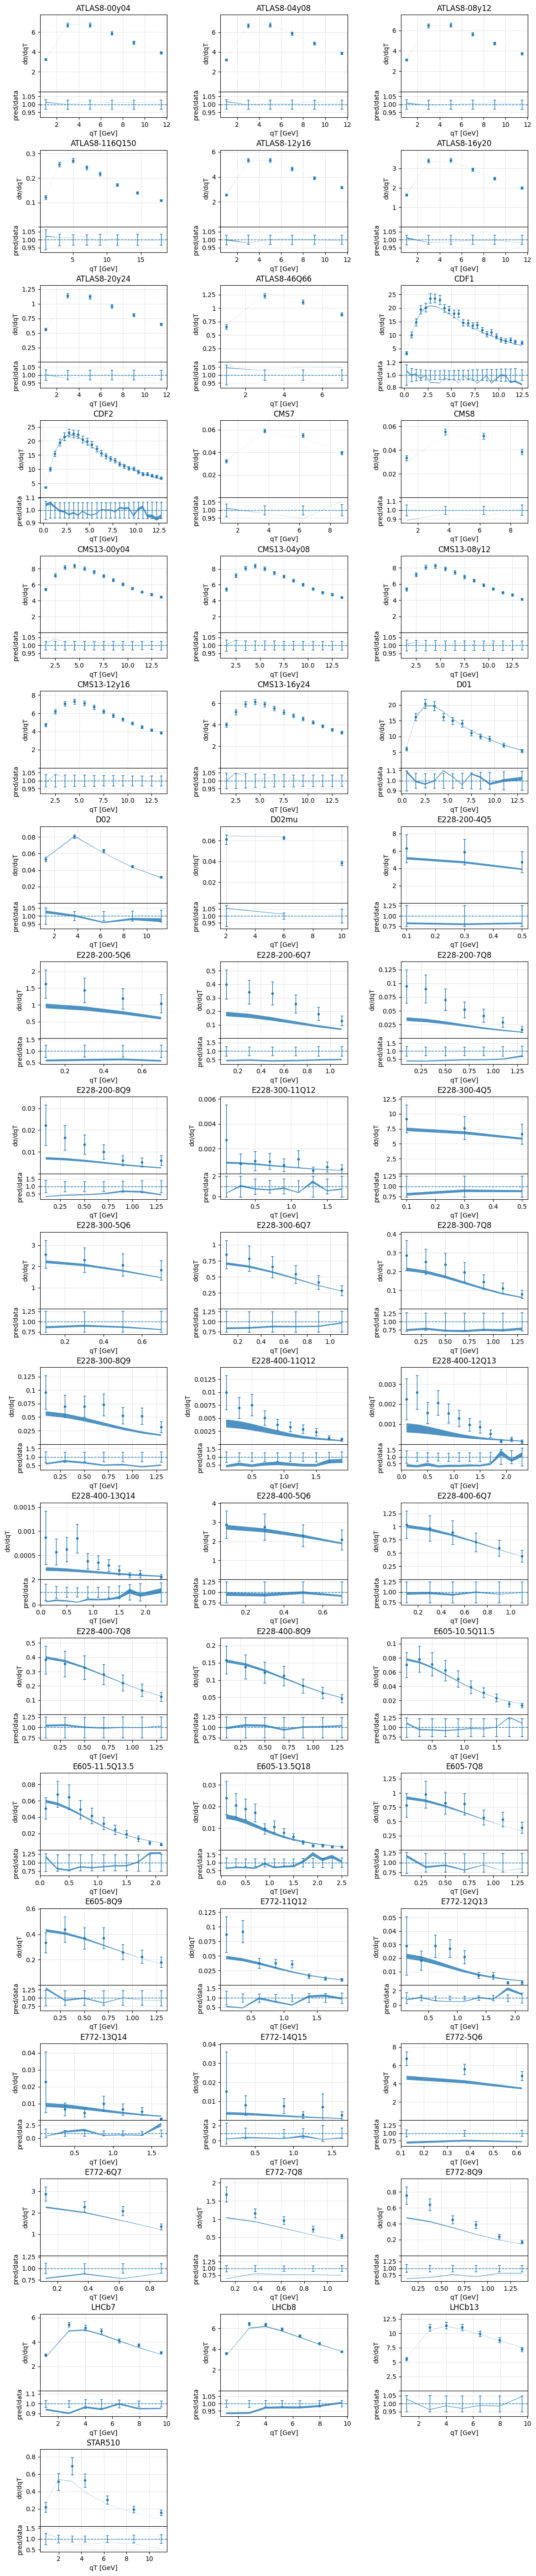

In [25]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

files_in_order = list(plots_list.keys())
max_cols_per_row = 3
n_files = len(files_in_order)
ncols = min(max_cols_per_row, n_files)
nrow_pairs = math.ceil(n_files / ncols)

fig = plt.figure(figsize=(4.6 * ncols, 3.8 * nrow_pairs))
outer = fig.add_gridspec(nrows=nrow_pairs, ncols=ncols, wspace=0.42, hspace=0.32)
hide_zero_label = FuncFormatter(lambda y, pos: "" if np.isclose(y, 0.0) else f"{y:g}")

def set_spectrum_ylim_band(ax, y_data, y_err, y_lo, y_hi, pad_frac=0.12):
    y_data = np.asarray(y_data, float)
    y_err  = np.asarray(y_err,  float)
    y_lo   = np.asarray(y_lo,   float)
    y_hi   = np.asarray(y_hi,   float)
    data_up = y_data + np.nan_to_num(y_err, nan=0.0)
    cand = np.concatenate([
        data_up[np.isfinite(data_up)],
        y_lo[np.isfinite(y_lo)],
        y_hi[np.isfinite(y_hi)]
    ])
    ymax = np.max(cand) if cand.size else 1.0
    ymax = 1.0 if not np.isfinite(ymax) or ymax <= 0 else ymax
    ax.set_ylim(0.0, np.nextafter(ymax * (1.0 + pad_frac), np.inf))

def set_ratio_ylim_band(ax, r_lo, r_hi, r_err, margin_frac=0.22, min_half_frac=0.08):
    r_lo = np.asarray(r_lo, float)
    r_hi = np.asarray(r_hi, float)
    r_err = np.asarray(r_err, float)
    lo = np.nanmin(r_lo[np.isfinite(r_lo)]) if np.isfinite(r_lo).any() else 1.0
    hi = np.nanmax(r_hi[np.isfinite(r_hi)]) if np.isfinite(r_hi).any() else 1.0
    if np.isfinite(r_err).any():
        max_err = float(np.nanmax(r_err))
        lo = min(lo, 1.0 - max_err)
        hi = max(hi, 1.0 + max_err)
    half_needed = max(1.0 - lo, hi - 1.0, 0.0)
    half = max(half_needed * (1.0 + margin_frac), min_half_frac)
    ax.set_ylim(1.0 - half, 1.0 + half)

for idx, fname in enumerate(files_in_order):
    r, c = divmod(idx, ncols)
    inner = outer[r, c].subgridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)
    ax_top = fig.add_subplot(inner[0, 0])
    ax_bot = fig.add_subplot(inner[1, 0], sharex=ax_top)

    d = plots_list[fname]
    qT        = d["qT_array"].to_numpy(float)
    data_vals = d["data_array"].to_numpy(float)
    data_err  = d["error_uncor_array"].to_numpy(float)

    # bands
    pred_lo = np.asarray(d["prediction_down_array"], float)
    pred_hi = np.asarray(d["prediction_up_array"],   float)
    rat_lo  = np.asarray(d["ratio_down_array"], float)
    rat_hi  = np.asarray(d["ratio_up_array"],   float)
    ratio_errs = d["error_uncor_ratio_array"].to_numpy(float)

    # --- Top: data with band ---
    ax_top.errorbar(qT, data_vals, yerr=data_err, fmt='o', ms=3, elinewidth=1, capsize=2, label="data")
    ax_top.fill_between(qT, pred_lo, pred_hi, alpha=0.8, label="prediction band", linewidth=0)
    ax_top.set_title(Path(fname).stem)
    ax_top.set_ylabel("dσ/dqT")
    ax_top.grid(True, alpha=0.3)
    set_spectrum_ylim_band(ax_top, data_vals, data_err, pred_lo, pred_hi)
    ax_top.yaxis.set_major_formatter(hide_zero_label)
    ax_top.tick_params(labelbottom=False)
    ax_top.spines['bottom'].set_visible(True)

    # --- Bottom: ratio band + data errors around 1 ---
    ax_bot.axhline(1.0, linestyle="--", linewidth=1)
    ax_bot.fill_between(qT, rat_lo, rat_hi, alpha=0.8, linewidth=0)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_errs, fmt='none', elinewidth=1, capsize=2)
    ax_bot.set_xlabel("qT [GeV]")
    ax_bot.set_ylabel("pred/data")
    ax_bot.grid(True, alpha=0.3)
    set_ratio_ylim_band(ax_bot, rat_lo, rat_hi, ratio_errs)
    ax_bot.spines['top'].set_visible(True)

plt.tight_layout()
plt.show()